# Smoke Detection in Remote Sensing Imagery

CBS 8th Semester — Machine Learning and Deep Learning Exam

In [118]:
#%pip install -q numpy pandas matplotlib scikit-learn scikit-image opencv-python pillow tifffile tensorflow keras imagehash
#%pip install datasets

#### Importing Libraries

In [150]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tifffile
from PIL import Image, ImageEnhance
from datasets import load_dataset
from collections import Counter
from sklearn.model_selection import train_test_split
import imagehash

### USTC_SmokeRS dataset

In [120]:
ustc = load_dataset("jonathan-roberts1/USTC_SmokeRS", split="train")

print(f"Total images : {len(ustc)}")
print(f"Features     : {ustc.features}")
print(f"Classes      : {ustc.features['label'].names}")

Total images : 6225
Features     : {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['cloud', 'dust', 'haze', 'land', 'seaside', 'smoke'])}
Classes      : ['cloud', 'dust', 'haze', 'land', 'seaside', 'smoke']


In [121]:
class_names = ustc.features["label"].names
counts = Counter(ustc["label"])

print("Class distribution:")
for idx, name in enumerate(class_names):
    print(f"  {name:<10} : {counts[idx]}")

Class distribution:
  cloud      : 1164
  dust       : 1009
  haze       : 1002
  land       : 1027
  seaside    : 1007
  smoke      : 1016


In [122]:
sample = np.array(ustc[0]["image"])
print(f"dtype  : {sample.dtype}")
print(f"shape  : {sample.shape}  (H × W × C)")

sizes = [np.array(row["image"]).shape[:2] for row in ustc.select(range(50))]
unique_sizes = set(sizes)
print(f"Unique sizes in first 50 samples: {unique_sizes}")

dtype  : uint8
shape  : (256, 256, 3)  (H × W × C)
Unique sizes in first 50 samples: {(256, 256)}


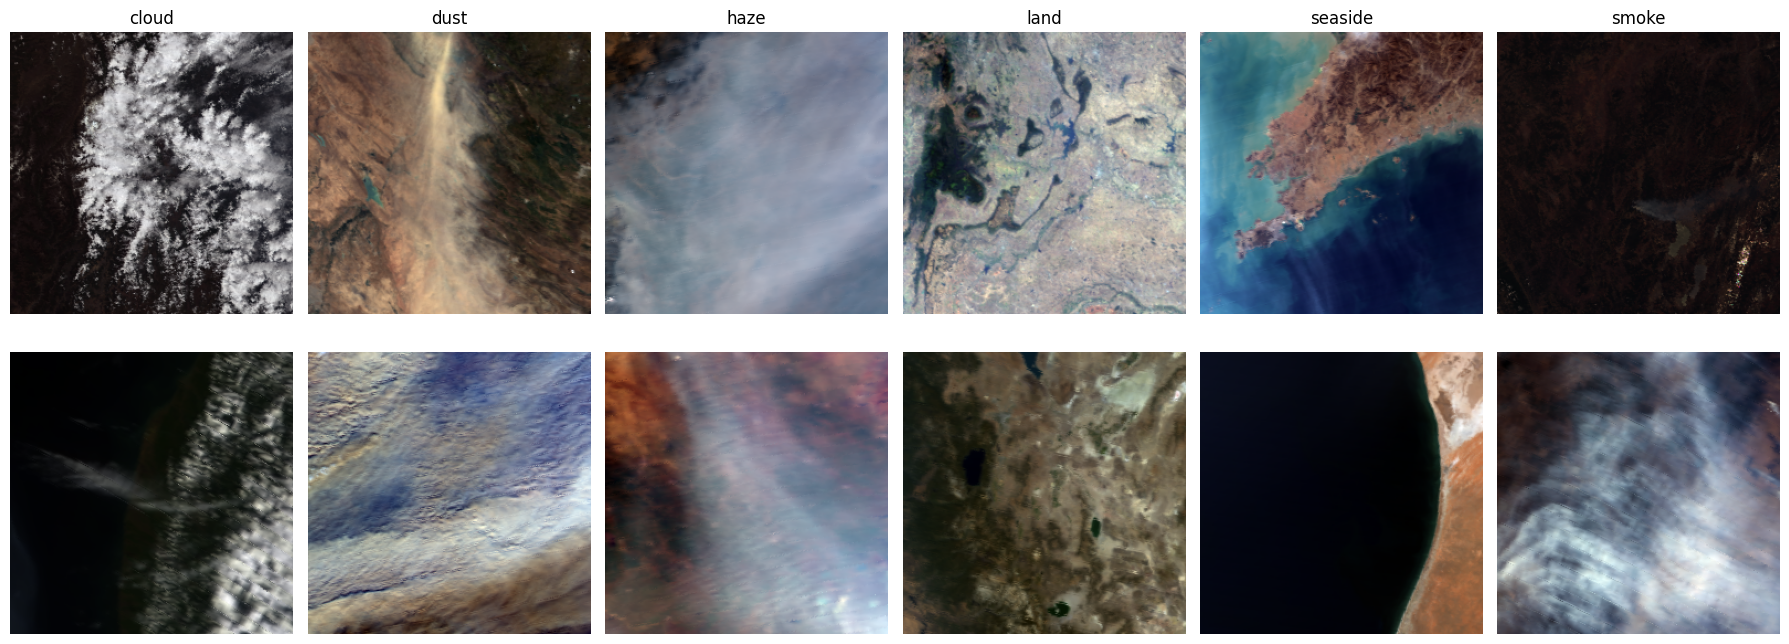

In [123]:
# ! REMOVE THE COMMENT THING

fig, axes = plt.subplots(2, 6, figsize=(18, 7))

for col, class_name in enumerate(class_names):
    idx = class_names.index(class_name)
    samples = [row for row in ustc if row["label"] == idx][:2]
    for row_i, s in enumerate(samples):
        axes[row_i][col].imshow(s["image"])
        axes[row_i][col].set_title(class_name if row_i == 0 else "")
        axes[row_i][col].axis("off")

plt.tight_layout()
plt.show()

### Data Preprocessing

In [124]:
TARGET_SIZE = (224, 224)

def load_ustc(pil_image):
    img = pil_image.resize(TARGET_SIZE, Image.BILINEAR)
    return np.array(img)

# verify
sample = load_ustc(ustc[0]["image"])
print(f"USTC loaded shape: {sample.shape}")

USTC loaded shape: (224, 224, 3)


In [125]:
pool = pd.DataFrame([
    {"index": i, "label": row["label"], "class": class_names[row["label"]]}
    for i, row in enumerate(ustc)
])

print(pool.groupby("class")["label"].count().rename("count"))
print(f"\nTotal: {len(pool)}")

pool.head()

class
cloud      1164
dust       1009
haze       1002
land       1027
seaside    1007
smoke      1016
Name: count, dtype: int64

Total: 6225


,index,label,class
0,0,0,cloud
1,1,0,cloud
2,2,0,cloud
3,3,0,cloud
4,4,0,cloud


In [126]:
train_val, test = train_test_split(pool, test_size=0.20, stratify=pool["label"], random_state=42)
train, val      = train_test_split(train_val, test_size=0.25, stratify=train_val["label"], random_state=42)

print(f"Train : {len(train)}  Val : {len(val)}  Test : {len(test)}")

Train : 3735  Val : 1245  Test : 1245


In [127]:
splits = {"train": train, "val": val, "test": test}

rows = []
for name in class_names:
    row = {"class": name}
    for split_name, df in splits.items():
        row[split_name] = (df["class"] == name).sum()
    rows.append(row)

df_split = pd.DataFrame(rows).set_index("class")
df_split["total"] = df_split.sum(axis=1)
for col in ["train", "val", "test"]:
    df_split[f"{col}%"] = (df_split[col] / df_split["total"] * 100).round(1)

df_split[["train", "val", "test", "train%", "val%", "test%"]]

,train,val,test,train%,val%,test%
class,,,,,,
cloud,698,233,233,60.0,20.0,20.0
dust,605,202,202,60.0,20.0,20.0
haze,602,200,200,60.1,20.0,20.0
land,616,206,205,60.0,20.1,20.0
seaside,604,201,202,60.0,20.0,20.1
smoke,610,203,203,60.0,20.0,20.0


### EDA (Training Set)

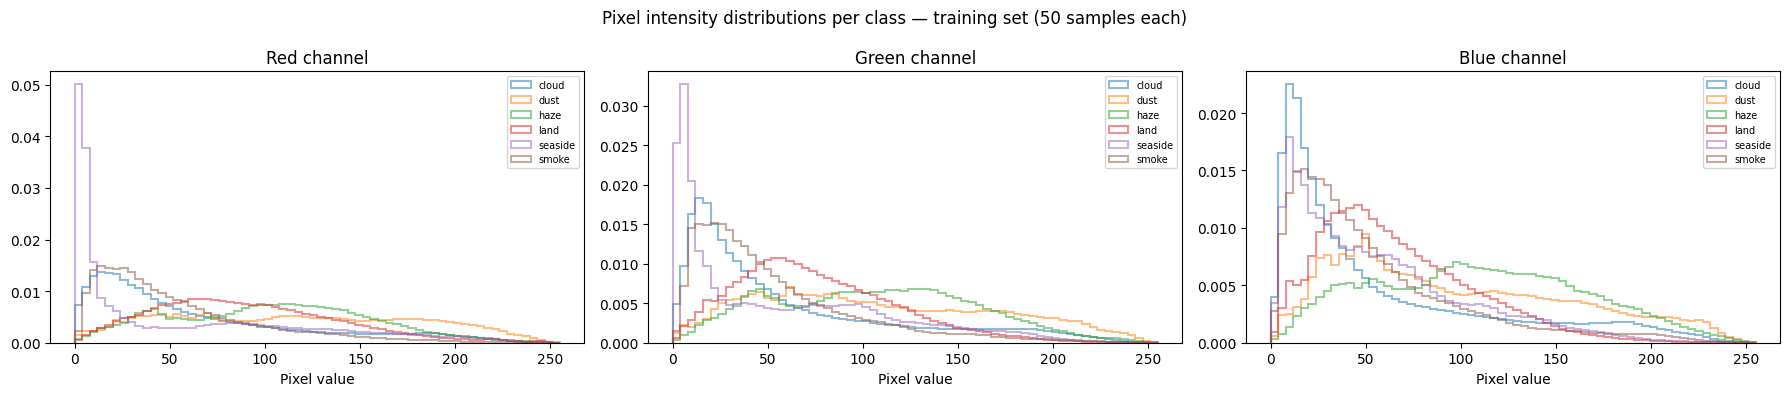

In [128]:
N_SAMPLE = 50
channel_labels = ["Red", "Green", "Blue"]
class_colors = plt.cm.tab10.colors

samples_per_class = {
    name: [ustc[i] for i in train[train["class"] == name]["index"].tolist()[:N_SAMPLE]]
    for name in class_names
}

def sample_pixels_ustc(rows):
    pixels = [[], [], []]
    for row in rows:
        img = np.array(row["image"])
        for c in range(3):
            pixels[c].append(img[:, :, c].flatten())
    return [np.concatenate(ch) for ch in pixels]

class_pixels = {name: sample_pixels_ustc(samples_per_class[name]) for name in class_names}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for c, ax in enumerate(axes):
    for i, name in enumerate(class_names):
        ax.hist(class_pixels[name][c], bins=64, range=(0, 255), alpha=0.5,
                color=class_colors[i], label=name, density=True, histtype="step", linewidth=1.5)
    ax.set_title(f"{channel_labels[c]} channel")
    ax.set_xlabel("Pixel value")
    ax.legend(fontsize=7)

plt.suptitle("Pixel intensity distributions per class — training set (50 samples each)")
plt.tight_layout()
plt.show()

In [129]:
for name in class_names:
    px = class_pixels[name]
    for c, ch in enumerate(channel_labels):
        print(f"{name:<10} {ch:6}: mean={px[c].mean():.1f}  std={px[c].std():.1f}")

cloud      Red   : mean=64.5  std=56.8
cloud      Green : mean=61.9  std=57.4
cloud      Blue  : mean=59.5  std=58.5
dust       Red   : mean=115.3  std=63.2
dust       Green : mean=107.7  std=61.4
dust       Blue  : mean=98.1  std=60.8
haze       Red   : mean=103.0  std=51.2
haze       Green : mean=106.1  std=52.5
haze       Blue  : mean=109.9  std=54.8
land       Red   : mean=90.3  std=47.7
land       Green : mean=75.9  std=41.3
land       Blue  : mean=66.6  std=39.3
seaside    Red   : mean=55.5  std=61.8
seaside    Green : mean=56.4  std=54.5
seaside    Blue  : mean=57.3  std=45.5
smoke      Red   : mean=53.2  std=42.4
smoke      Green : mean=53.4  std=43.1
smoke      Blue  : mean=55.2  std=46.3


In [130]:
rows_eda = []
for name in class_names:
    for row in samples_per_class[name]:
        img = np.array(row["image"]).astype(np.float64)
        rows_eda.append({"class": name, "mean": img.mean(), "std": img.std()})

df_eda = pd.DataFrame(rows_eda)
df_eda.groupby("class")[["mean", "std"]].mean().round(1).rename(columns={"mean": "avg brightness"})

,avg brightness,std
class,,
cloud,62.0,47.2
dust,107.0,41.7
haze,106.3,37.6
land,77.6,35.9
seaside,56.4,47.2
smoke,53.9,32.6


### Data Filtering

#### Checking for duplicates

In [131]:
def ahash(pil_image, hash_size=12):
    img = pil_image.convert("L").resize((hash_size, hash_size), Image.BILINEAR)
    arr = np.array(img, dtype=np.float32)
    return int(np.packbits((arr > arr.mean()).flatten()).tobytes().hex(), 16)

seen = {}
duplicate_indices = []
for i in pool["index"]:
    h = ahash(ustc[i]["image"])
    if h in seen:
        duplicate_indices.append(i)
    else:
        seen[h] = i

print(f"Images checked   : {len(pool)}")
print(f"Duplicates found : {len(duplicate_indices)}")
if duplicate_indices:
    print(f"Flagged indices  : {duplicate_indices}")

Images checked   : 6225
Duplicates found : 1
Flagged indices  : [5196]


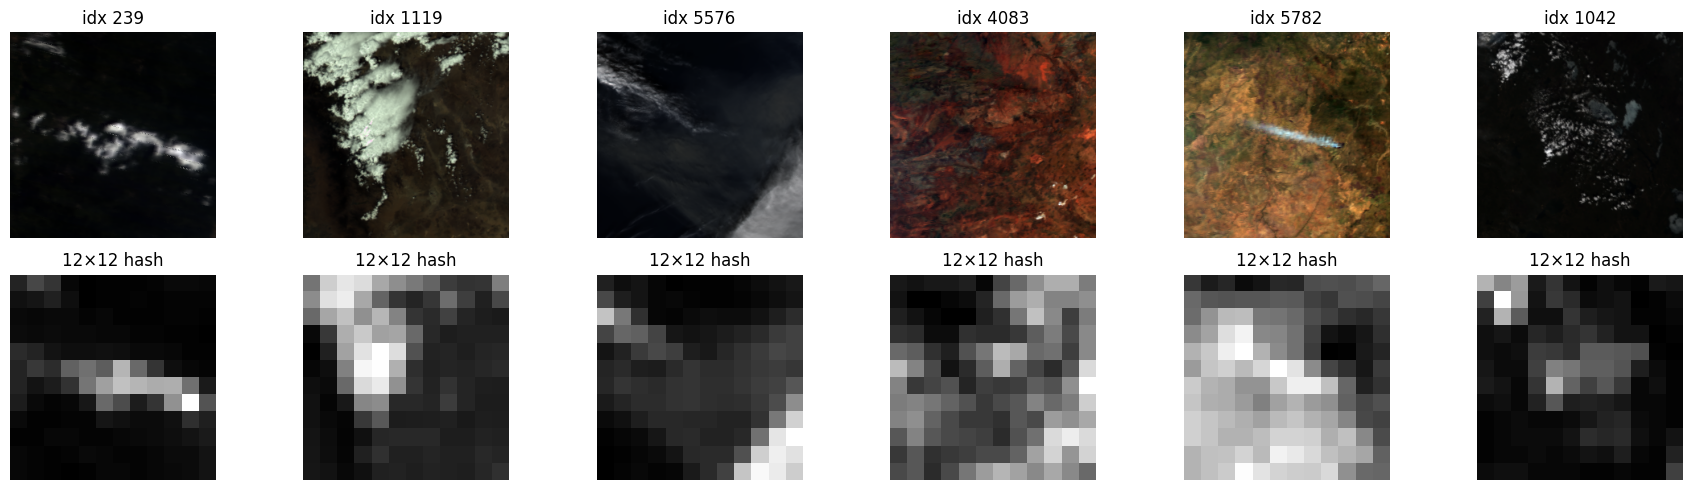

In [132]:
# THIS WAS MADE TO HELP US UNDERSTAND HOW THE HASHING ACTUALLY WORK 

n_show = 6
sample_indices = pool["index"].sample(n_show, random_state=42).tolist()

fig, axes = plt.subplots(2, n_show, figsize=(18, 5))
for col, idx in enumerate(sample_indices):
    img_orig = ustc[idx]["image"]
    img_small = img_orig.convert("L").resize((12, 12), Image.BILINEAR)

    axes[0][col].imshow(img_orig)
    axes[0][col].set_title(f"idx {idx}")
    axes[0][col].axis("off")

    axes[1][col].imshow(img_small, cmap="gray", interpolation="nearest")
    axes[1][col].set_title("12×12 hash")
    axes[1][col].axis("off")

plt.tight_layout()
plt.show()

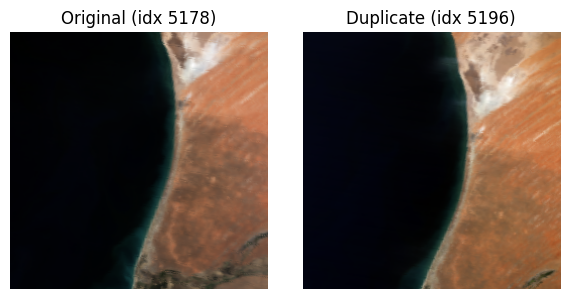

In [133]:
if duplicate_indices:
    fig, axes = plt.subplots(len(duplicate_indices), 2, figsize=(6, 3 * len(duplicate_indices)))
    if len(duplicate_indices) == 1:
        axes = [axes]
    for ax_row, dup_idx in zip(axes, duplicate_indices):
        orig_idx = seen[ahash(ustc[dup_idx]["image"])]
        ax_row[0].imshow(ustc[orig_idx]["image"])
        ax_row[0].set_title(f"Original (idx {orig_idx})")
        ax_row[0].axis("off")
        ax_row[1].imshow(ustc[dup_idx]["image"])
        ax_row[1].set_title(f"Duplicate (idx {dup_idx})")
        ax_row[1].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No duplicates to display.")


In [134]:
# ANOTHER WAY TO CHECK FOR DUPLICATES

seen_ph = {}
duplicate_indices_ph = []
for i in pool["index"]:
    h = imagehash.phash(ustc[i]["image"])
    if h in seen_ph:
        duplicate_indices_ph.append(i)
    else:
        seen_ph[h] = i

print(f"Images checked   : {len(pool)}")
print(f"Duplicates found : {len(duplicate_indices_ph)}")
if duplicate_indices_ph:
    for dup_idx in duplicate_indices_ph:
        orig_idx = seen_ph[imagehash.phash(ustc[dup_idx]["image"])]
        print(f"  Flagged idx {dup_idx} matches idx {orig_idx}")

Images checked   : 6225
Duplicates found : 0


#### Check for currput or unreadable images

In [135]:
corrupt_indices = []
for i in pool["index"]:
    try:
        img = np.array(ustc[i]["image"])
        assert img.ndim == 3 and img.shape[2] == 3
    except Exception:
        corrupt_indices.append(i)

print(f"Images checked  : {len(pool)}")
print(f"Corrupt found   : {len(corrupt_indices)}")
if corrupt_indices:
    print(f"Flagged indices : {corrupt_indices}")

Images checked  : 6225
Corrupt found   : 0


#### RGB anomalies

In [136]:
anomaly_indices = []
for i in pool["index"]:
    avg = np.array(ustc[i]["image"]).mean()
    if avg < 5 or avg > 250:
        anomaly_indices.append(i)

print(f"Images checked  : {len(pool)}")
print(f"Anomalies found : {len(anomaly_indices)}")
if anomaly_indices:
    print(f"Flagged indices : {anomaly_indices}")

Images checked  : 6225
Anomalies found : 0


### Data Normalisation

In [137]:
def normalise(img):
    return img.astype(np.float32) / 255.0

# verify
sample = load_ustc(ustc[0]["image"])
print(f"Before: min={sample.min()}  max={sample.max()}  dtype={sample.dtype}")
norm = normalise(sample)
print(f"After : min={norm.min():.1f}  max={norm.max():.1f}  dtype={norm.dtype}")

Before: min=6  max=245  dtype=uint8
After : min=0.0  max=1.0  dtype=float32


In [138]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def normalise_imagenet(img):
    return (img.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD

# verify
norm_in = normalise_imagenet(sample)
print(f"Shape : {norm_in.shape}")
print(f"Mean  : {norm_in.mean(axis=(0,1)).round(3)}  (expect near 0)")
print(f"Std   : {norm_in.std(axis=(0,1)).round(3)}   (expect near 1)")

Shape : (224, 224, 3)
Mean  : [-0.658 -0.6   -0.346]  (expect near 0)
Std   : [1.118 1.175 1.18 ]   (expect near 1)


In [140]:
def load_split(df, normalise_fn):
    X = np.stack([normalise_fn(load_ustc(ustc[i]["image"])) for i in df["index"]])
    y = df["label"].values
    return X, y

# verify on a small sample
sample_df = train.sample(5, random_state=0)
X_sample, y_sample = load_split(sample_df, normalise)
print(f"Shape : {X_sample.shape}  dtype: {X_sample.dtype}")
print(f"Range : [{X_sample.min():.2f}, {X_sample.max():.2f}]")
print(f"Labels: {y_sample}")

Shape : (5, 224, 224, 3)  dtype: float32
Range : [0.00, 0.99]
Labels: [4 0 4 5 5]


### Data Augmentation (training set only)

In [170]:
def aug_flip(img):
    return img.transpose(Image.FLIP_LEFT_RIGHT)

def aug_rotate(img):
    return img.rotate(random.choice([90, 180, 270]))

def aug_brightness(img):
    return ImageEnhance.Brightness(img).enhance(random.uniform(0.5, 2))

def aug_noise(img):
    arr = np.array(img, dtype=np.float32)
    arr += np.random.normal(0, 10, arr.shape)
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

AUG_FUNCS  = [aug_flip, aug_rotate, aug_brightness, aug_noise]
AUG_LABELS = ["flip", "rotate", "brightness", "noise"]

In [171]:
original = train.assign(aug=0, aug_label="original")
augmented = [train.assign(aug=i+1, aug_label=label) for i, label in enumerate(AUG_LABELS)]

train_aug = pd.concat([original] + augmented, ignore_index=True)

print(f"Before augmentation : {len(train):>5} images")
print(f"After augmentation  : {len(train_aug):>5} images  ({len(train_aug)//len(train)}×)")

Before augmentation :  3735 images
After augmentation  : 18675 images  (5×)


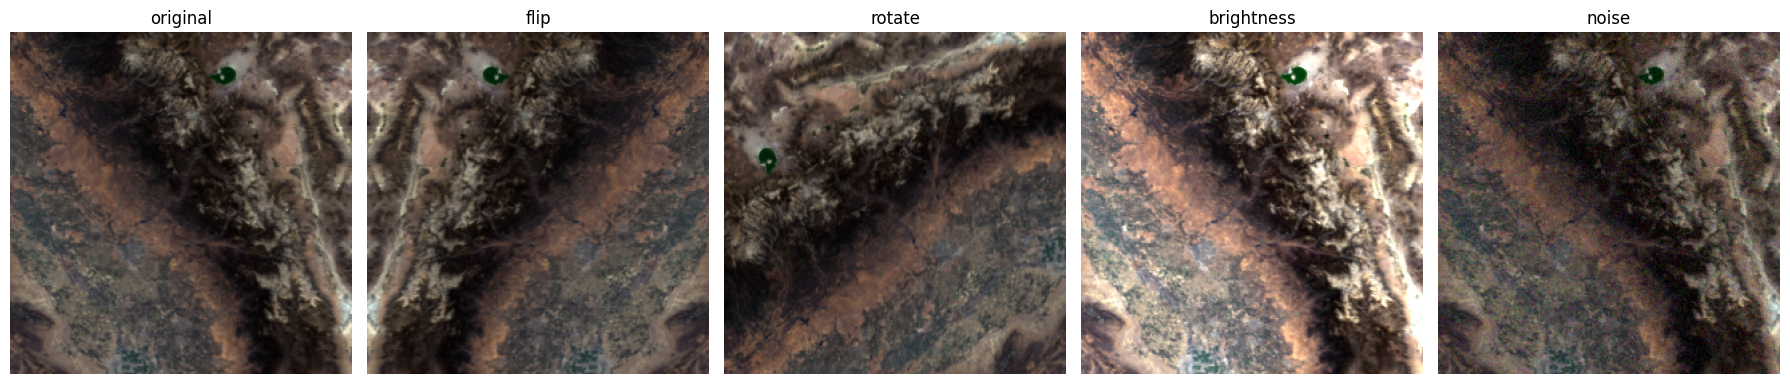

In [172]:
sample_idx = train["index"].iloc[0]
pil_img = ustc[sample_idx]["image"]

aug_versions = [("original", pil_img)] + [(label, fn(pil_img)) for label, fn in zip(AUG_LABELS, AUG_FUNCS)]

fig, axes = plt.subplots(1, len(aug_versions), figsize=(18, 4))
for ax, (label, img) in zip(axes, aug_versions):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()